In [5]:
import pandas as pd

train_df=pd.read_csv("../data/processed/clean_train_df.csv")
eval_df=pd.read_csv("../data/processed/clean_eval_df.csv")
holdout_df = pd.read_csv("../data/processed/clean_holdout_df.csv")


In [9]:
# Ensure datetime
train_df["date"] = pd.to_datetime(train_df["date"])
eval_df["date"] = pd.to_datetime(eval_df["date"])
holdout_df["date"] = pd.to_datetime(holdout_df["date"])

In [12]:
#Date features

def add_date_features(df):
    df["year"] = df["date"].dt.year
    df["quarter"] = df["date"].dt.quarter
    df["month"] = df["date"].dt.month

     # Reorder columns
    df.insert(1, "year", df.pop("year"))
    df.insert(2, "quarter", df.pop("quarter"))
    df.insert(3, "month", df.pop("month"))

    return df


In [13]:

train_df = add_date_features(train_df)
eval_df = add_date_features(eval_df)
holdout_df = add_date_features(holdout_df)  

In [15]:
train_df.head()


,date,year,quarter,month,median_sale_price,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,...,Total Housing Units,Median Rent,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,city_full
0,2012-03-31,2012,1,3,46550.0,217450.0,31.813674,110.183666,14.0,23.0,...,2677.0,710.0,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,200773.999557,Atlanta-Sandy Springs-Alpharetta
1,2012-03-31,2012,1,3,200000.0,7500.0,104.931794,79.265873,1.0,1.0,...,1108.0,641.0,94600.0,1171.0,52.0,2376.0,2376.0,1018.0,105863.681174,Pittsburgh
2,2012-03-31,2012,1,3,75750.0,92400.0,165.898618,63.412698,2.0,2.0,...,1252.0,627.0,62800.0,894.0,30.0,2106.0,2106.0,807.0,60152.096646,Pittsburgh
3,2012-03-31,2012,1,3,79900.0,79900.0,0.696203,0.000000,1.0,1.0,...,208.0,534.0,66200.0,216.0,7.0,414.0,414.0,208.0,44042.242632,Pittsburgh
4,2012-03-31,2012,1,3,196000.0,198000.0,122.807018,124.060150,1.0,1.0,...,692.0,484.0,79300.0,711.0,61.0,1489.0,1489.0,641.0,126572.277873,Pittsburgh


In [ ]:
#  Frequency Encoding (zipcode)

zip_counts=train_df["zipcode"].value_counts()

train_df["zipcode_freq"]=train_df["zipcode"].map(zip_counts)
eval_df["zipcode_freq"]=eval_df["zipcode"].map(zip_counts).fillna(0)
holdout_df["zipcode_freq"]=holdout_df["zipcode"].map(zip_counts).fillna(0)

print("zip freq example(train):")
print(train_df[["zipcode","zipcode_freq"]].head())



zip freq example(train):
   zipcode  zipcode_freq
0    30002            94
1    15469            94
2    15468            94
3    15466            94
4    15464            94


In [18]:
# Traget encoding (city_full)
from category_encoders import TargetEncoder


te= TargetEncoder(cols=["city_full"])

train_df["city_encoded"]=te.fit_transform(train_df["city_full"],train_df["price"])
eval_df["city_encoded"]=te.transform(eval_df["city_full"])
holdout_df["city_encoded"]=te.transform(holdout_df["city_full"])

print("City encoding example (train):")

print(train_df[["city_full", "city_encoded"]].head())


                          city_full   city_encoded
0  Atlanta-Sandy Springs-Alpharetta  192482.567621
1                        Pittsburgh  130439.789927
2                        Pittsburgh  130439.789927
3                        Pittsburgh  130439.789927
4                        Pittsburgh  130439.789927


In [19]:
# drop unused columns

drop_cols=["date","city_full","city","zipcode","median_sale_price"]
train_df.drop(columns=drop_cols,inplace=True)
eval_df.drop(columns=drop_cols,inplace=True)

holdout_df.drop(columns=drop_cols,inplace=True)



In [23]:
print(train_df.shape)
train_df.head(1)

(585244, 38)


,year,quarter,month,median_list_price,median_ppsf,median_list_ppsf,homes_sold,pending_sales,new_listings,inventory,...,Median Rent,Median Home Value,Total Labor Force,Unemployed Population,Total School Age Population,Total School Enrollment,Median Commute Time,price,zipcode_freq,city_encoded
0,2012,1,3,217450.0,31.813674,110.183666,14.0,23.0,44.0,64.0,...,710.0,279500.0,3171.0,460.0,5408.0,5408.0,2492.0,200773.999557,94,192482.567621


In [22]:
train_df.to_csv("../data/processed/feature_engineered_train.csv")
eval_df.to_csv("../data/processed/feature_engineered_eval.csv")
holdout_df.to_csv("../data/processed/feature_engineered_holdout.csv")

In [25]:
#Multicolinearity

import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def calculate_vif(df, target_col=None):
    """
    Calculate Variance Inflation Factor (VIF) for each numeric column in df.
    """
    # Keep only numeric columns
    numeric_df = df.select_dtypes(include=['float64', 'int64']).copy()

    # Drop target if provided
    if target_col and target_col in numeric_df.columns:
        numeric_df = numeric_df.drop(columns=[target_col])

    # Add constant for statsmodels
    X = add_constant(numeric_df)

    # Compute VIF (skip the first column = constant)
    vif_data = pd.DataFrame()
    vif_data["feature"] = numeric_df.columns
    vif_data["VIF"] = [
        variance_inflation_factor(X.values, i + 1)  # skip constant at index 0
        for i in range(len(numeric_df.columns))
    ]

    return vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)


# Look at VIF and correlation with original training dataset
df = pd.read_csv("../data/raw/train.csv")
vif_table = calculate_vif(df, target_col="price")
print(vif_table)


d:\DataScience\personal_projects\housing_price_prediction\housing_price_prediction\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                         feature          VIF
0        Total School Enrollment          inf
1    Total School Age Population          inf
2               Total Population  6600.440350
3              Total Labor Force   839.557009
4            Median Commute Time   650.528668
5   Total Families Below Poverty   573.705680
6            Total Housing Units    21.298479
7                   new_listings    19.930888
8                     homes_sold    13.409262
9          Unemployed Population    12.881559
10                    restaurant    10.915101
11                          bank    10.680631
12                   supermarket     9.630326
13                 pending_sales     9.241440
14             Median Home Value     6.826955
15                     inventory     5.887100
16                          park     5.676253
17                        school     5.657422
18                       station     4.654858
19             Per Capita Income     4.619926
20                   Median Rent  

How to interpret

- VIF > 10 → serious multicollinearity.

- VIF > 100 → catastrophic (drop/re-engineer immediately).

- VIF = ∞ → perfect linear redundancy (drop one).

In [26]:
offenders = ["Total Population", "Total Labor Force", "Total Families Below Poverty"]
corr_matrix = df[offenders].corr()
corr_matrix

,Total Population,Total Labor Force,Total Families Below Poverty
Total Population,1.000000,0.985715,0.998992
Total Labor Force,0.985715,1.000000,0.985703
Total Families Below Poverty,0.998992,0.985703,1.000000


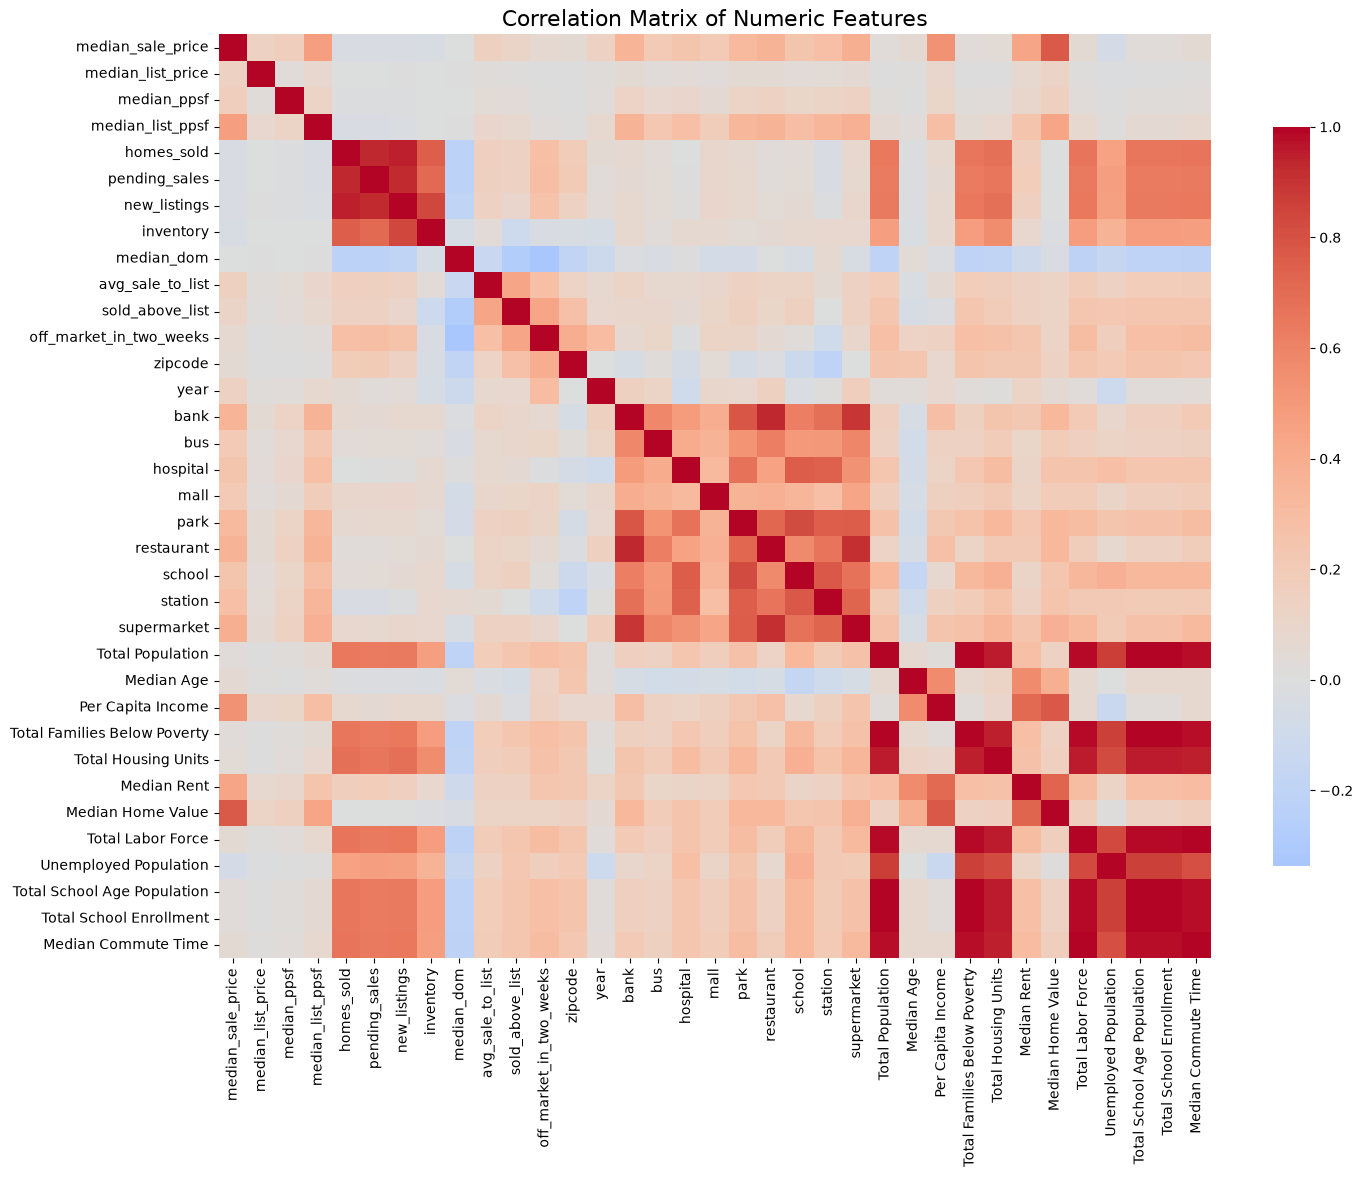

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric features (exclude the target 'price')
numeric_df = df.select_dtypes(include=['float64', 'int64']).drop(columns=["price"], errors="ignore")

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Display full matrix as heatmap
plt.figure(figsize=(16,12))
sns.heatmap(
    corr_matrix, 
    cmap="coolwarm", 
    center=0, 
    annot=False,   # set to True if you want numbers on cells
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix of Numeric Features", fontsize=16)
plt.show()


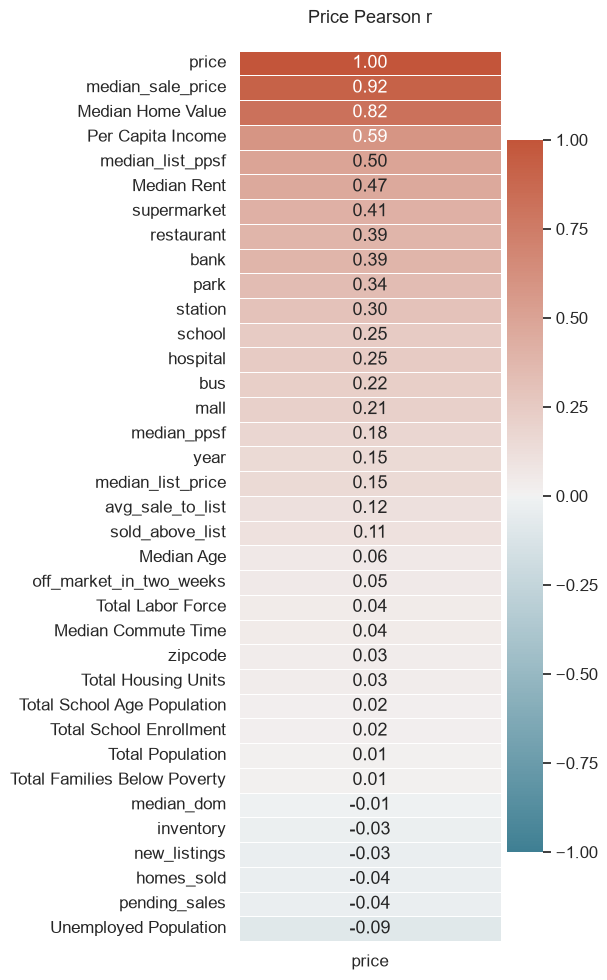

In [28]:
# Compute correlations with price
num_cols = df.select_dtypes("number").columns
corr_vec  = df[num_cols].corr(method="pearson")["price"].sort_values(ascending=False)
sns.set_theme(style="white")     
sns.set(font_scale=1.1)          
plt.figure(figsize=(6,10))       
ax = sns.heatmap(
        corr_vec.to_frame(),     
        annot=True, fmt=".2f",
        vmin=-1, vmax=1,         
        cmap=sns.diverging_palette(220, 20, as_cmap=True),
        center=0,
        linewidths=.5, linecolor="white",
        cbar_kws={"shrink":0.8, "pad":0.02}
     )
ax.set_title("Price Pearson r", pad=20)
ax.set_ylabel("")                 
ax.set_xlabel("")
plt.tight_layout()
plt.show()